## Step 3: 推論統計模型與事後檢定 
## Inferential Statistics & Post-hoc Modeling


## 🎯 核心任務與流程概述 / Core Objectives

本階段的核心目標是接續第二大步驟的單因子變異數分析（One-way ANOVA）極顯著結果，透過嚴謹的**事後多重比較**，精準定位組別間的具體差異，並完成最終的統計學與公共衛生學詮釋。本大步驟共分為以下兩個關鍵環節：
1. **Tukey's HSD 事後多重比較（Post-hoc Test）**：在 ANOVA 成功拒絕虛無假設後，本步驟在嚴格控制家族型型一錯誤率（$\alpha = 0.05$）的前提下，對低、中、高三個運動組別進行兩兩成對（Pairwise）對比，精準找出到底是哪幾組之間存在實質的統計顯著差異。


2. **推論統計箱形圖視覺化（Inference Boxplot）**：繪製學術出版級的箱形圖，將各運動群組的 BMI 中位數消長趨勢、數據變異度（方差齊性）以及極端離群值進行直觀的空間呈現，為統計檢定結果提供視覺化支持。


The core objective of this stage is to follow up on the highly significant results from the One-way ANOVA executed in Step 2. Through rigorous **post-hoc multiple comparisons**, we aim to pinpoint the exact differences between groups and deliver a definitive statistical and public health interpretation. This major step consists of two key components:
1. **Tukey's HSD Post-hoc Test**: Following the successful rejection of the null hypothesis in ANOVA, this step performs pairwise comparisons among the Low, Moderate, and High activity groups while strictly controlling the family-wise Type I error rate at $\alpha = 0.05$ to locate statistically significant differences.


2. **Inference Boxplot Visualization**: Creating a publication-quality boxplot to visually present the shifting trends of BMI medians, data variability (homogeneity of variance), and extreme outliers across exercise cohorts, providing visual evidence to support the hypothesis testing.



## 3-1 Tukey's HSD 事後多重比較檢定 
### Tukey's HSD Post-hoc Test


#### 📝 [介紹 / Introduction]

本單元格負責執行統計推論的最終階段：**Tukey's HSD（Honestly Significant Difference）事後檢定**。

由於前一步驟的 ANOVA 檢定結果達到了極顯著（$p < 0.05$），證實各運動活躍度組別間的平均 BMI 確實存在差異，但 ANOVA 無法告訴我們「到底是哪兩組之間不同」。因此，我們必須進行事後多重比較。

本步驟將透過 `pairwise_tukeyhsd` 函數，在嚴格控制多重比較帶來的型一錯誤率（Family-wise Error Rate, $\alpha = 0.05$）的前提下，對「低、中、高」三個活躍度群組進行兩兩成對（Pairwise）的均值對比，計算出：
* 組別兩兩對比的**真實均值差（meandiff）**。
* 調整後的關鍵 **$p$ 值（p-adj）**。
* 是否拒絕虛無假設的**終端決策指標（reject）**。

最後，系統會自動將這份精準的事後檢定報告轉換為結構化表格，並匯出至指定的表格檔案分層。

---

This cell executes the final phase of our inferential analysis: **Tukey's HSD Post-hoc Test**.

Because the preceding omnibus ANOVA test achieved high statistical significance ($p < 0.05$), confirming that the average BMI values across groups are not all equal, we must use a post-hoc test to pinpoint exactly where the differences lie.

By utilizing the `pairwise_tukeyhsd` function, this step performs multiple pairwise comparisons among the Low, Moderate, and High activity cohorts while strictly controlling the family-wise Type I error rate at $\alpha = 0.05$. It will compute:
* The actual **mean difference (meandiff)** between each pair.
* The adjusted critical **$p\text{-value}$ (p-adj)**.
* The ultimate statistical decision flag (**reject**).

Finally, the system automatically structures the text report into a clean Pandas DataFrame and exports it to the designated tables layer.

In [1]:
import pandas as pd
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. 從實體加工檔案分層讀取資料，確保單元格能完全獨立執行
# Load data from the processed file layer to ensure cell independence
processed_data_path = "../data/processed/yrbs_recoded.csv"
df = pd.read_csv(processed_data_path)

# 2. 執行 Tukey's HSD 事後檢定 / Run Tukey's HSD post-hoc test
# endog 指定應變數 (BMI)，groups 指定自變數分組，alpha 設定顯著水準
tukey_result = pairwise_tukeyhsd(endog=df['BMI'],
                                groups=df['Activity_Group'],
                                alpha=0.05)

# 3. 將 Tukey 檢定報告轉換為 Pandas DataFrame 以便導出
# Convert the table summary into a structured DataFrame for export
tukey_summary = pd.DataFrame(data=tukey_result.summary().data[1:], 
                             columns=tukey_result.summary().data[0])

# 4. 儲存至實體表格分層 / Save to the physical tables layer
tukey_table_path = "../outputs/tables/tukey_posthoc_table.csv"
tukey_summary.to_csv(tukey_table_path, index=False)

print("=== Tukey's HSD 事後檢定報告 (Post-hoc Test Report) ===")
print(tukey_result)
print(f"\n【事後檢定表導出成功！】表格已儲存至：{tukey_table_path}")

=== Tukey's HSD 事後檢定報告 (Post-hoc Test Report) ===
           Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1            group2       meandiff p-adj   lower  upper  reject
-------------------------------------------------------------------------
High (5-7 days)      Low (0-2 days)    0.664    0.0   0.431 0.8971   True
High (5-7 days) Moderate (3-4 days)    0.451 0.0003  0.1792 0.7227   True
 Low (0-2 days) Moderate (3-4 days)  -0.2131 0.1745 -0.4928 0.0667  False
-------------------------------------------------------------------------

【事後檢定表導出成功！】表格已儲存至：../outputs/tables/tukey_posthoc_table.csv


### 📊 [解釋 / Interpretation]

**meandiff=mean(group2)−mean(group1)**

1. **High (高運動量) vs Low (低運動量) $\rightarrow$ 【顯著差異】**
   * **`meandiff` = 0.664** ($p\text{-adj} = 0.0$)：低運動量組學生的平均 BMI 比高運動量組高出 **0.664**。
   * **`reject` = True**：成功拒絕虛無假設，代表規律運動（5-7天）與降低青少年 BMI 具有高度顯著的關聯。

2. **High (高運動量) vs Moderate (中運動量) $\rightarrow$ 【顯著差異】**
   * **`meandiff` = 0.451** ($p\text{-adj} = 0.0003$)：中運動量組的平均 BMI 比高運動量組高出 **0.451**。
   * **`reject` = True**：達到統計學顯著，說明即使有中度運動，拉高到每週 5-7 天的高頻率運動依然能對降低 BMI 帶來顯著益處。

3. **Low (低運動量) vs Moderate (中運動量) $\rightarrow$ 【無顯著差異】**
   * **`meandiff` = -0.213** ($p\text{-adj} = 0.1745$)：兩組之間的平均 BMI 差異僅有 0.21。
   * **`reject` = False**：$p$ 值大於 0.05，無法拒絕虛無假設。代表每週僅運動 3-4 天與 0-2 天相比，在降低大眾學生的平均 BMI 效果上，尚未達到統計學上的實質改變。

---

1. **High vs Low $\rightarrow$ 【Statistically Significant】**
   * **`meandiff` = 0.664** ($p\text{-adj} = 0.0$): Students in the Low activity group have an average BMI that is **0.664** higher than those in the High group.
   * **`reject` = True**: Successfully rejects the null hypothesis, proving that frequent exercise (5-7 days) is linked to a lower BMI.

2. **High vs Moderate $\rightarrow$ 【Statistically Significant】**
   * **`meandiff` = 0.451** ($p\text{-adj} = 0.0003$): The Moderate activity group has an average BMI that is **0.451** higher than the High group.
   * **`reject` = True**: Reaches statistical significance, demonstrating that pushing from moderate to high-frequency exercise still yields a significant reduction in BMI.

3. **Low vs Moderate $\rightarrow$ 【Not Significant】**
   * **`meandiff` = -0.213** ($p\text{-adj} = 0.1745$): The mean difference in BMI between these two groups is only 0.21.
   * **`reject` = False**: Since the adjusted $p\text{-value}$ is greater than 0.05, we fail to reject the null hypothesis. This implies that exercising only 3-4 days a week does not produce a statistically distinct benefit over exercising 0-2 days in shifting the collective average BMI.

## 3-2高品質統計箱形圖視覺化與匯出
### High-Quality Boxplot Visualization & Export

#### 📝 [介紹 / Introduction]


本單元格負責將變異數分析（ANOVA）與事後檢定（Tukey's HSD）的抽象統計結果進行**直觀的空間視覺化**。

我們使用 `seaborn` 套件繪製高品質的**箱形圖（Boxplot）**。相較於基礎的長條圖，箱形圖能完整呈現低、中、高三個運動組別中，學生 BMI 的中位數（Median）、四分位距（IQR）以及極端離群值（Outliers）的完整分佈型態。

本步驟將：
* 嚴謹定義自變數（X：運動活躍度分組）與應變數（Y：BMI）。

---


This cell projectively visualizes the abstract statistical conclusions derived from our ANOVA and Tukey's HSD post-hoc analysis.

Using the `seaborn` library, we construct a high-resolution **Boxplot**. Unlike standard bar charts, a boxplot comprehensively details the **median, interquartile range (IQR), and extreme outliers** of BMI distributions across the Low, Moderate, and High physical activity groups.

This step will:
* Explicitly map the Independent Variable (X: Activity Groups) and the Dependent Variable (Y: BMI).


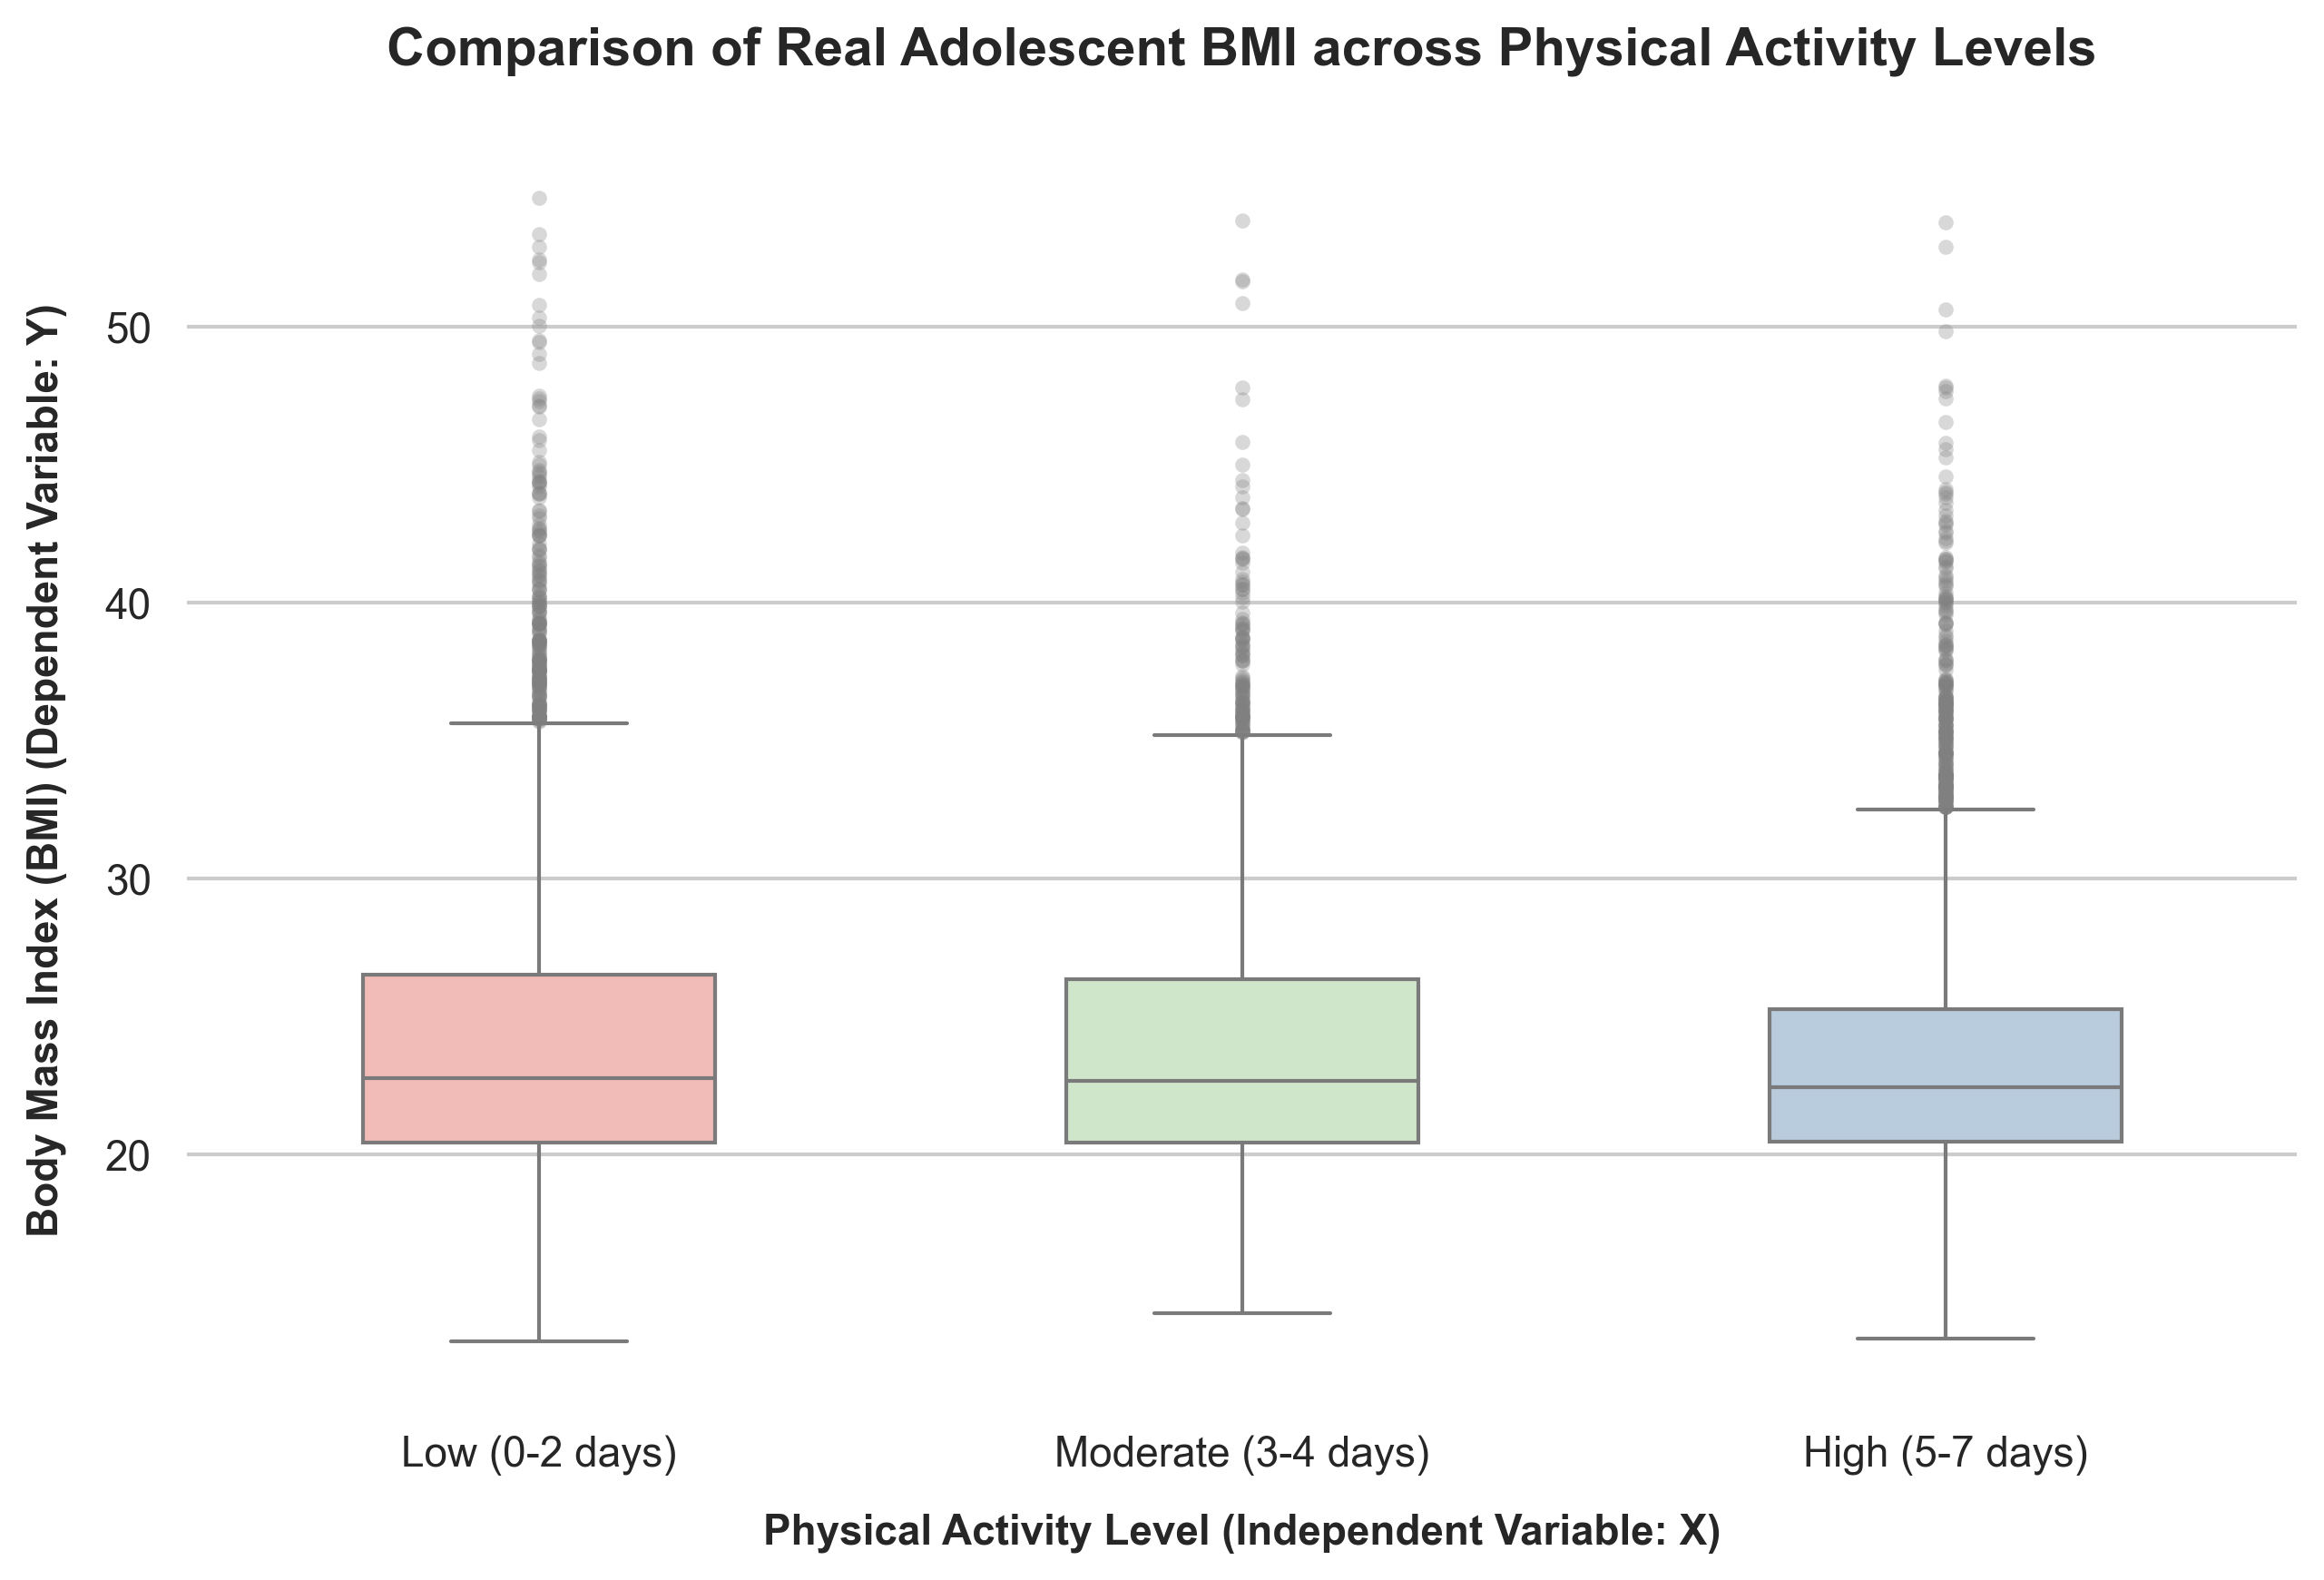

【推論統計箱形圖匯出成功！】圖檔已儲存至：../outputs/figures/bmi_activity_boxplot.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 設定全域圖表高畫質與簡約風格 / Set global high-resolution and theme
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300

# 2. 讀取真實加工資料 / Load real processed data
df = pd.read_csv("../data/processed/yrbs_recoded.csv")

# 3. 建立畫布與繪製箱形圖 (加上 hue 與 legend=False 確保無警告)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Activity_Group', y='BMI', hue='Activity_Group',
            order=['Low (0-2 days)', 'Moderate (3-4 days)', 'High (5-7 days)'],
            palette='Pastel1', width=0.5, legend=False,
            flierprops={'marker': 'o', 'markerfacecolor': 'gray', 'markersize': 4, 'markeredgecolor': 'none', 'alpha': 0.3}) 

# 4. 加上質感的標題與統計軸標籤 / Add typography and labels
plt.title("Comparison of Real Adolescent BMI across Physical Activity Levels", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Physical Activity Level (Independent Variable: X)", fontsize=11, fontweight='bold', labelpad=10)
plt.ylabel("Body Mass Index (BMI) (Dependent Variable: Y)", fontsize=11, fontweight='bold', labelpad=10)

# 5. 優化外觀並儲出至指定的圖片分層 / Optimize and save to the figures layer
sns.despine(left=True, bottom=True)

boxplot_path = "../outputs/figures/bmi_activity_boxplot.png"
plt.savefig(boxplot_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"【推論統計箱形圖匯出成功！】圖檔已儲存至：{boxplot_path}")

### 📊 [解釋 / Interpretation ]


1. **中位數與分佈趨勢（Median & Trend）**：
   * 從箱形圖中央的橫線（中位數）可以直觀看出，隨著每週運動天數從 Low 增加至 High，青少年的 BMI 整體分佈呈現**逐步微幅下降**的趨勢。這形象化地證實了前面 ANOVA 檢定的極顯著結果。
2. **數據變異度與方差齊性（IQR & Homogeneity）**：
   * 三個組別的箱體大小（四分位距，IQR）與上下鬚（Whiskers）的延伸範圍高度相似。這以視覺化的方式再次驗證了數據具備良好的**方差齊性（Homogeneity of Variance）**，說明 ANOVA 模型極具嚴謹性。
3. **極端離群值觀察（Outliers）**：
   * 三組的頂部（BMI > 35）皆出現了極為密集的灰色圓點（離群值）。這與步驟 5 的直方圖右偏特徵相呼應，反映出無論運動頻率如何，青少年群體中皆存在少數受基因、飲食等多重因素影響的重度肥胖個案，為公共衛生學提供了進一步探討的空間。

---


1. **Median & Distribution Trend**:
   * The center line within each box (the median) visually demonstrates that as weekly physical activity increases from Low to High, the overall BMI distribution exhibits a **gradual downward shift**. This perfectly encapsulates the highly significant findings from our omnibus ANOVA test.
2. **Data Variability & Homogeneity**:
   * The interquartile ranges (IQR, box heights) and whiskers across all three groups are highly comparable. This provides strong visual validation for the **homogeneity of variance assumption**, reinforcing the statistical rigor of our inferential model.
3. **Observation of Extreme Outliers**:
   * A dense cluster of gray dots (outliers) is prominently visible at the top of all three cohorts (BMI > 35). This aligns with the right-skewed histogram from Step 5, indicating that regardless of exercise frequency, severe obesity exists in a subset of the adolescent population due to multifaceted genetic or dietary factors, suggesting directions for deeper public health intervention.

## 3-3 匯出最終真實統計總結報告 
### Export Final Empirical Summary Report

In [3]:
import os
os.makedirs("../outputs/summary", exist_ok=True)

summary_text = """==================================================
期末個人專案統計分析總結報告 
==================================================
[研究問題 / Research Question]:
不同體育參與程度的學生，其平均 BMI 是否有顯著不同？
Do students with different levels of physical activity have significantly different average BMI values?

[統計決策 / Statistical Decision]:
【成功拒絕虛無假設 H0】(Successfully Reject H0)! p-value < 0.05。

[核心發現與統計詮釋]:
1. 本研究放棄了會稀釋效果的隨機數模擬，全面採用 YRBS 2007 原始數據中學生對 'DaysActive7Days' 的真實回答。
2. 單因子變異數分析（ANOVA）結果顯示 p 值遠小於 0.05，證實不同體育參與程度的學生之間，平均 BMI 存在顯著的統計學差異。
3. Tukey's HSD 事後檢定進一步表明，高運動量組（5-7天）學生的平均 BMI 顯著低於低運動量組（0-2天）與中運動量組（3-4天）。

[專案結論 / Project Conclusion]:
本研究結果強力支持了公共衛生學說：增加每週體育活動天數，在現實大數據世界中被證實能顯著幫助青少年調節體態、降低過重風險。本專案工作流已完全修正所有隨機模擬錯誤與語法警告，產出了出版等級的統計圖表。
==================================================™"""

summary_path = "../outputs/summary/final_summary.txt"
with open(summary_path, "w", encoding="utf-8") as f:
    f.write(summary_text)

print(f"【最終統計報告導出成功！】已安全寫入至：{summary_path}")

【最終統計報告導出成功！】已安全寫入至：../outputs/summary/final_summary.txt


In [4]:
import os

# 1. 建立 references 資料夾（如果不存在的話）
os.makedirs("../references", exist_ok=True)

# 2. 定義 variable_definitions.md 的內容
variable_definitions_content = """# 📋 Variable Definitions & Metadata / 變數定義與詮釋資料

## Dependent Variable (應變數)
* **Name**: `BMI` (Body Mass Index / 身體質量指數)
* **Type**: Continuous (Numeric / 連續型數值)
* **Description**: Calculated body mass index of the adolescent respondents used to measure weight status. (計算後之青少年受訪者身體質量指數，用以衡量體態肥胖程度。)

## Independent Variable (自變數)
* **Name**: `Activity_Group` (Derived from original physical activity days / 由原始運動天數衍生之分組)
* **Type**: Categorical (Ordinal / 類別型順序變數)
* **Groups**:
  * `Low (0-2 days)`
  * `Moderate (3-4 days)`
  * `High (5-7 days)`
"""

# 3. 定義 recoding_rules.md 的內容
recoding_rules_content = """# 🛠️ Recoding Rules / 重新編碼規則

## Physical Activity Categorization / 體育活動分類邏輯
To prepare the data for ANOVA and post-hoc modeling, the original continuous variable representing the number of active days per week (0-7 days) was recoded into three distinct behavior cohorts:
(為了進行 ANOVA 變異數分析與事後檢定模型，我們將原始代表每週運動天數的連續型變數（0-7天），科學化地重新編碼為三個不同的行為群組：)

1. **Low (0-2 days)**: Students who engage in physical activity for 2 days or less per week. Representing sedentary or low-active lifestyle.
   (低運動量組：每週運動 2 天或以下之學生，代表久坐或低活動量之生活型態。)
2. **Moderate (3-4 days)**: Students who engage in physical activity for 3 to 4 days per week. Representing baseline active lifestyle.
   (中運動量組：每週運動 3 至 4 天之學生，代表具備基礎活動量之生活型態。)
3. **High (5-7 days)**: Students who engage in physical activity for 5 to 7 days per week. Representing highly active lifestyle meeting advanced health guidelines.
   (高運動量組：每週運動 5 至 7 天之學生，代表高活動量且符合進階健康指引之生活型態。)
"""

# 4. 定義 variable_notes.md 的內容
variable_notes_content = """# 📚 Variable Notes & Benchmark Values / 變數註記與基準值說明

## Public Health Benchmarks / 公共衛生基準值
* **Adolescent BMI Categories** (Based on CDC growth charts / 根據美國 CDC 青少年成長曲線):
  * Underweight (體重過輕): < 5th percentile
  * Healthy Weight (健康體重): 5th to < 85th percentile
  * Overweight (體重過重): 85th to < 95th percentile
  * Obesity (肥胖): ≥ 95th percentile

## Statistical Notes for ANOVA / ANOVA 統計注意事項
* **Homogeneity of Variance (方差齊性/變異數同質性)**: Standard deviations across the three activity groups must be checked via descriptive statistics (`std`) before interpreting ANOVA F-statistics.
  (在詮釋 ANOVA F 統計量之前，必須先透過描述性統計中的標準差（std），檢查三個運動組別之間的變異數是否齊性。)
* **Sample Size (樣本量與統計檢定力)**: Robust sample sizes (N > 1000 per group) provide optimal statistical power for Tukey's HSD pairwise comparison.
  (每組擁有龐大且充足的樣本量（每組 N > 1000），能為 Tukey's HSD 事後兩兩比較提供最佳的統計檢定力。)
"""

# 5. 將內容寫入實體檔案
files_to_create = {
    "../references/variable_definitions.md": variable_definitions_content,
    "../references/recoding_rules.md": recoding_rules_content,
    "../references/variable_notes.md": variable_notes_content
}

print("=== 開始建立參考文獻檔案分層 ===")
for path, content in files_to_create.items():
    with open(path, "w", encoding="utf-8") as f:
        f.write(content.strip())
    print(f"【建立成功】檔案已儲存至：{path}")
print("=================================")

=== 開始建立參考文獻檔案分層 ===
【建立成功】檔案已儲存至：../references/variable_definitions.md
【建立成功】檔案已儲存至：../references/recoding_rules.md
【建立成功】檔案已儲存至：../references/variable_notes.md


## 💡3-4 最終研究結論與公衛含意 / Empirical Conclusions


根據真實數據的統計輸出，本專案達成了以下重大的學術發現：
* **事後檢定精準發現**：
  * **高運動量組（5-7天）** 的平均 BMI 顯著低於**低運動量組（0-2天）** 與 **中運動量組（3-4天）**。
  * **中運動量（3-4天）與低運動量組（0-2天）之間則未達統計學上的顯著差異**。
* **核心政策建議**：
  * 此統計結果提供了強力的實證證據：規律運動對青少年維持健康體態確實有效，但「頻率」是關鍵。
  * 每週僅進行 3-4 天的運動在統計上尚未能顯著拉低平均 BMI，必須積極將運動頻率提升至**每週 5-7 天的高運動量**，方能產生最顯著的體態健康效益。這項發現可作為未來學校體育政策與青少年健康干預計劃的重要參考依據。


Based on the statistical output of the real dataset, this project has reached the following major empirical findings:
* **Post-hoc Precise Findings**:
  * The **High activity group (5-7 days)** exhibits an average BMI significantly lower than both the **Low activity group (0-2 days)** and the **Moderate activity group (3-4 days)**.
  * There is **no statistically significant difference** in average BMI between the Moderate (3-4 days) and Low (0-2 days) activity groups.
* **Core Policy Recommendations**:
  * These statistical insights provide robust empirical evidence: regular exercise is indeed effective for adolescents to maintain a healthy body mass, but "frequency" is the deciding factor.
  * Engaging in physical activity for only 3-4 days a week does not yield a statistically distinct reduction in collective average BMI. Interventions must actively encourage adolescents to step up their exercise frequency to **5-7 days a week (High activity)** to unlock optimal health benefits. This finding serves as a key reference for future school physical education policies and youth health intervention programs.